# Depth Encoder for Sleep Posture Classification

This notebook focuses on building the **Depth Encoder** branch for our multimodal sleep posture classification system. The goal of this encoder is to learn meaningful feature representations from **depth images** captured under different in-bed conditions, including **uncover, cover1, and cover2**.

Depth data is especially important in this project because it preserves **3D geometric information** about the sleeper’s body posture and is expected to be more robust than RGB under **blanket occlusion** and other visibility challenges. The encoder developed here will later serve as one of the shared modality-specific backbones in our multimodal fusion framework.

## Objectives
- Load and preprocess depth images from the dataset amd use posture labels
- Train a depth-based encoder for **3-class posture classification**
- Evaluate its unimodal performance
- Save the learned encoder weights for later use in multimodal fusion benchmarking

## Expected Output
A trained **depth encoder** that extracts discriminative posture-related features and can be reused in later experiments involving:
- late fusion
- attention-based fusion
- joint-guided fusion

This notebook is part of the broader project on **multimodal sleep posture analysis for sleep apnea risk screening**.

# Import Libraries

In [21]:
import torch
import torchvision
import os
import pandas as pd
from PIL import Image
from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

## Check device / CUDA

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("CUDA is not available. Training will run on CPU.")

Using device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


In [3]:
print(torch.__version__)
print(torchvision.__version__)

2.10.0+cu126
0.25.0+cu126


## Load Depth Metadata and Images

In [4]:
def load_depth_metadata(csv_path: str) -> pd.DataFrame:
    """
    Load the posture CSV and keep only depth rows.
    """
    df = pd.read_csv(csv_path)
    df_depth = df[df["modality"] == "depth"].copy()
    df_depth.reset_index(drop=True, inplace=True)
    return df_depth

In [5]:
def load_depth_image(dataset_root: str, relative_image_path: str) -> Image.Image:
    """
    Load a depth image from its relative path in the CSV.
    """
    full_path = os.path.join(dataset_root, relative_image_path)

    if not os.path.exists(full_path):
        raise FileNotFoundError(f"Image not found: {full_path}")

    image = Image.open(full_path).convert("L")  # depth image as single-channel grayscale
    return image

In [6]:
def get_depth_sample(df_depth: pd.DataFrame, idx: int, dataset_root: str):
    """
    Load one sample (image + label + metadata) from the filtered depth dataframe.
    """
    row = df_depth.iloc[idx]

    image = load_depth_image(dataset_root, row["image_path"])
    label = int(row["label_id"])

    sample = {
        "image": image,
        "label": label,
        "label_name": row["label"],
        "subject_id": row["subject_id"],
        "condition": row["condition"],
        "image_index": row["image_index"],
        "image_path": row["image_path"],
    }

    return sample

In [8]:
dataset_root = Path(r"C:\Users\arshi\Desktop\AIS\Sem-2\Intelligent Sensing Systems\Practise Module\Project\Dataset\SLP2022\SLP\danaLab")
csv_path = dataset_root / "posture_labels_all_modalities.csv"

df_depth = load_depth_metadata(csv_path)
print(df_depth.shape)
df_depth.head()

(13770, 8)


,subject_id,modality,condition,image_index,image_path,label,label_id,source
0,1,depth,uncover,1,00001/depth/uncover/image_000001.png,supine,0,inferred_ordering
1,1,depth,uncover,2,00001/depth/uncover/image_000002.png,supine,0,inferred_ordering
2,1,depth,uncover,3,00001/depth/uncover/image_000003.png,supine,0,inferred_ordering
3,1,depth,uncover,4,00001/depth/uncover/image_000004.png,supine,0,inferred_ordering
4,1,depth,uncover,5,00001/depth/uncover/image_000005.png,supine,0,inferred_ordering


Label ID: 0
Label Name: supine
Subject ID: 1
Condition: uncover


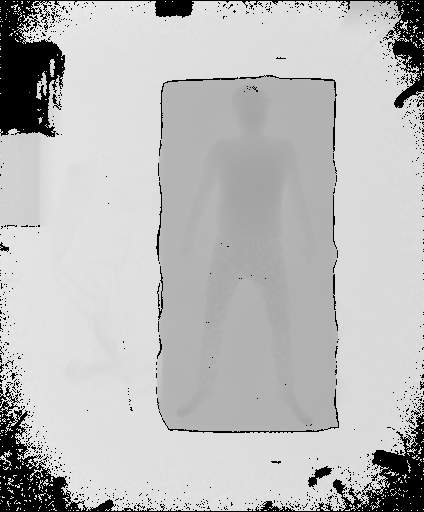

In [9]:
sample = get_depth_sample(df_depth, idx=0, dataset_root=dataset_root)

print("Label ID:", sample["label"])
print("Label Name:", sample["label_name"])
print("Subject ID:", sample["subject_id"])
print("Condition:", sample["condition"])

sample["image"]

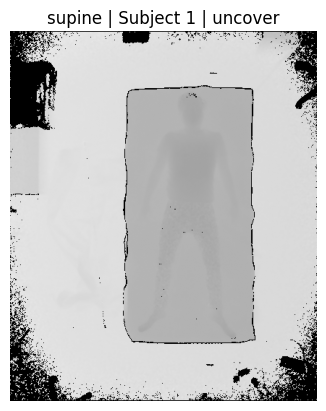

In [11]:
import matplotlib.pyplot as plt

plt.imshow(sample["image"], cmap="gray")
plt.title(f'{sample["label_name"]} | Subject {sample["subject_id"]} | {sample["condition"]}')
plt.axis("off")
plt.show()

## Create Subject-Wise Train, Validation, and Test Splits

In [14]:
def create_subjectwise_splits(
    df,
    subject_col="subject_id",
    train_size=0.70,
    val_size=0.15,
    test_size=0.15,
    random_state=42,
):
    """
    Create subject-wise train/val/test splits.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe (e.g., filtered depth dataframe).
    subject_col : str
        Column containing subject IDs.
    train_size : float
        Fraction of subjects for training.
    val_size : float
        Fraction of subjects for validation.
    test_size : float
        Fraction of subjects for testing.
    random_state : int
        Seed for reproducibility.

    Returns
    -------
    train_df, val_df, test_df, train_subjects, val_subjects, test_subjects
    """
    total = train_size + val_size + test_size
    if abs(total - 1.0) > 1e-8:
        raise ValueError("train_size + val_size + test_size must sum to 1.0")

    subjects = sorted(df[subject_col].astype(str).unique())

    train_subjects, temp_subjects = train_test_split(
        subjects,
        test_size=(1 - train_size),
        random_state=random_state,
        shuffle=True,
    )

    # Split remaining subjects into val and test
    val_ratio_within_temp = val_size / (val_size + test_size)

    val_subjects, test_subjects = train_test_split(
        temp_subjects,
        train_size=val_ratio_within_temp,
        random_state=random_state,
        shuffle=True,
    )

    train_subjects = sorted(train_subjects)
    val_subjects = sorted(val_subjects)
    test_subjects = sorted(test_subjects)

    train_df = df[df[subject_col].astype(str).isin(train_subjects)].copy()
    val_df   = df[df[subject_col].astype(str).isin(val_subjects)].copy()
    test_df  = df[df[subject_col].astype(str).isin(test_subjects)].copy()

    train_df.reset_index(drop=True, inplace=True)
    val_df.reset_index(drop=True, inplace=True)
    test_df.reset_index(drop=True, inplace=True)

    return train_df, val_df, test_df, train_subjects, val_subjects, test_subjects

In [15]:
def verify_subjectwise_splits(train_df, val_df, test_df, subject_col="subject_id"):
    train_subjects = set(train_df[subject_col].astype(str).unique())
    val_subjects = set(val_df[subject_col].astype(str).unique())
    test_subjects = set(test_df[subject_col].astype(str).unique())

    print("Train subjects:", len(train_subjects))
    print("Val subjects:  ", len(val_subjects))
    print("Test subjects: ", len(test_subjects))
    print()

    print("Train samples:", len(train_df))
    print("Val samples:  ", len(val_df))
    print("Test samples: ", len(test_df))
    print()

    print("Train ∩ Val overlap: ", len(train_subjects & val_subjects))
    print("Train ∩ Test overlap:", len(train_subjects & test_subjects))
    print("Val ∩ Test overlap:  ", len(val_subjects & test_subjects))

In [18]:
def show_split_distributions(train_df, val_df, test_df, label_col="label", condition_col="condition"):
    print("=== Label distribution ===")
    print("\nTrain:")
    print(train_df[label_col].value_counts().sort_index())

    print("\nValidation:")
    print(val_df[label_col].value_counts().sort_index())

    print("\nTest:")
    print(test_df[label_col].value_counts().sort_index())

    print("\n=== Condition distribution ===")
    print("\nTrain:")
    print(train_df[condition_col].value_counts().sort_index())

    print("\nValidation:")
    print(val_df[condition_col].value_counts().sort_index())

    print("\nTest:")
    print(test_df[condition_col].value_counts().sort_index())

In [19]:
train_df, val_df, test_df, train_subjects, val_subjects, test_subjects = create_subjectwise_splits(
    df_depth,
    subject_col="subject_id",
    train_size=0.70,
    val_size=0.15,
    test_size=0.15,
    random_state=42
)

verify_subjectwise_splits(train_df, val_df, test_df, subject_col="subject_id")
show_split_distributions(train_df, val_df, test_df, label_col="label", condition_col="condition")

Train subjects: 71
Val subjects:   15
Test subjects:  16

Train samples: 9585
Val samples:   2025
Test samples:  2160

Train ∩ Val overlap:  0
Train ∩ Test overlap: 0
Val ∩ Test overlap:   0
=== Label distribution ===

Train:
label
left      3195
right     3195
supine    3195
Name: count, dtype: int64

Validation:
label
left      675
right     675
supine    675
Name: count, dtype: int64

Test:
label
left      720
right     720
supine    720
Name: count, dtype: int64

=== Condition distribution ===

Train:
condition
cover1     3195
cover2     3195
uncover    3195
Name: count, dtype: int64

Validation:
condition
cover1     675
cover2     675
uncover    675
Name: count, dtype: int64

Test:
condition
cover1     720
cover2     720
uncover    720
Name: count, dtype: int64


In [20]:
print(train_df.head())
print(val_df.head())
print(test_df.head())

   subject_id modality condition  image_index  \
0           2    depth   uncover            1   
1           2    depth   uncover            2   
2           2    depth   uncover            3   
3           2    depth   uncover            4   
4           2    depth   uncover            5   

                             image_path   label  label_id             source  
0  00002/depth/uncover/image_000001.png  supine         0  inferred_ordering  
1  00002/depth/uncover/image_000002.png  supine         0  inferred_ordering  
2  00002/depth/uncover/image_000003.png  supine         0  inferred_ordering  
3  00002/depth/uncover/image_000004.png  supine         0  inferred_ordering  
4  00002/depth/uncover/image_000005.png  supine         0  inferred_ordering  
   subject_id modality condition  image_index  \
0           5    depth   uncover            1   
1           5    depth   uncover            2   
2           5    depth   uncover            3   
3           5    depth   uncover   

## Create Depth Dataset and DataLoaders

In [22]:
# -----------------------------
# 1. Image transforms
# -----------------------------
def get_depth_transforms(image_size=(224, 224)):
    """
    Returns train and evaluation transforms for depth images.
    Depth images are loaded as single-channel grayscale.
    """
    train_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),  # shape: [1, H, W]
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])

    eval_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])

    return train_transform, eval_transform

In [23]:
# -----------------------------
# 2. Dataset
# -----------------------------
class DepthDataset(Dataset):
    def __init__(self, dataframe, dataset_root, transform=None):
        self.df = dataframe.reset_index(drop=True).copy()
        self.dataset_root = Path(dataset_root)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = self.dataset_root / row["image_path"]
        label = int(row["label_id"])

        if not image_path.exists():
            raise FileNotFoundError(f"Image not found: {image_path}")

        image = Image.open(image_path).convert("L")  # single-channel depth image

        if self.transform:
            image = self.transform(image)

        return image, label

In [24]:
# -----------------------------
# 3. DataLoader creation
# -----------------------------
def create_depth_dataloaders(
    train_df,
    val_df,
    test_df,
    dataset_root,
    image_size=(224, 224),
    batch_size=32,
    num_workers=0
):
    train_transform, eval_transform = get_depth_transforms(image_size=image_size)

    train_dataset = DepthDataset(train_df, dataset_root, transform=train_transform)
    val_dataset   = DepthDataset(val_df, dataset_root, transform=eval_transform)
    test_dataset  = DepthDataset(test_df, dataset_root, transform=eval_transform)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )

    return train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader

In [25]:
# -----------------------------
# 4. Batch sanity check
# -----------------------------
def inspect_dataloader_batch(dataloader, class_names=None):
    images, labels = next(iter(dataloader))

    print("Batch image tensor shape:", images.shape)
    print("Batch label tensor shape:", labels.shape)
    print("Batch labels:", labels[:10].tolist())

    if class_names is not None:
        decoded = [class_names[label] for label in labels[:10].tolist()]
        print("Decoded labels:", decoded)

In [26]:
# -----------------------------
# 5. Visualize a few samples
# -----------------------------
def show_depth_batch(dataloader, class_names=None, num_images=6):
    images, labels = next(iter(dataloader))

    num_images = min(num_images, len(images))
    fig, axes = plt.subplots(1, num_images, figsize=(3 * num_images, 3))

    if num_images == 1:
        axes = [axes]

    for i in range(num_images):
        img = images[i].squeeze(0).cpu().numpy()

        # de-normalize for display
        img = (img * 0.5) + 0.5

        axes[i].imshow(img, cmap="gray")
        if class_names:
            axes[i].set_title(class_names[int(labels[i])])
        else:
            axes[i].set_title(f"Label: {int(labels[i])}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

In [27]:
class_names = {
    0: "supine",
    1: "left",
    2: "right"
}

train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader = create_depth_dataloaders(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    dataset_root=dataset_root,
    image_size=(224, 224),
    batch_size=32,
    num_workers=0
)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 9585
Validation dataset size: 2025
Test dataset size: 2160


Batch image tensor shape: torch.Size([32, 1, 224, 224])
Batch label tensor shape: torch.Size([32])
Batch labels: [1, 1, 2, 0, 0, 1, 2, 2, 0, 2]
Decoded labels: ['left', 'left', 'right', 'supine', 'supine', 'left', 'right', 'right', 'supine', 'right']


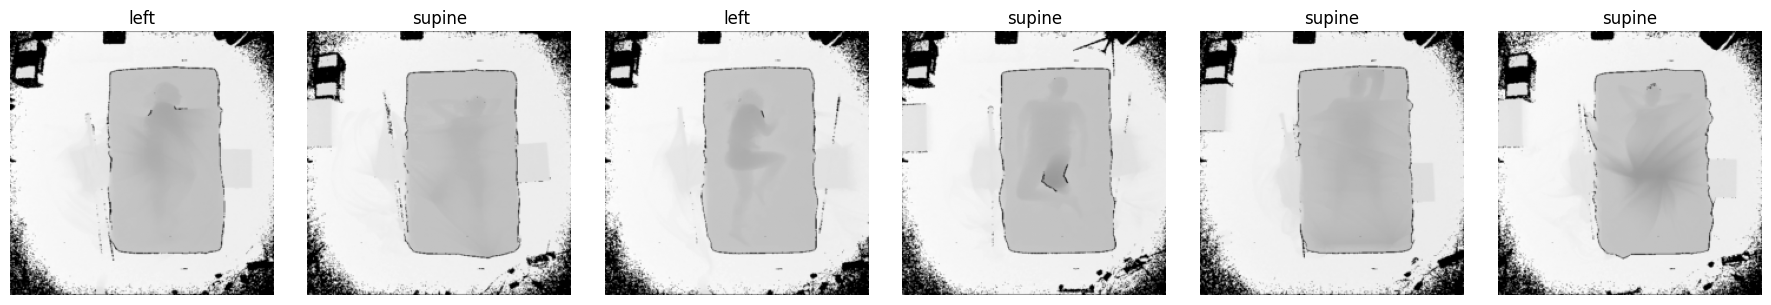

In [28]:
inspect_dataloader_batch(train_loader, class_names=class_names)
show_depth_batch(train_loader, class_names=class_names, num_images=6)

## Define the Depth CNN Encoder Architecture